本节课，我们将正式进入GPT的学习。ChatGPT是一种强大的语言模型，其核心原理在于：根据已给出的上文，逐字预测并生成接下来的内容。通俗地讲，就是模型依据已有文字，不断“猜测”下一个最可能出现的字符，从而连贯地输出完整文本。而支撑这一能力的底层架构，源自2017年发表的划时代论文《Attention Is All You Need》所提出的Transformer。GPT是Generative Pre-trained Transformer的缩写，所以Transformer是支撑这一切的底层神经网络。

当然，我们这节课的目标并非训练一个完整的ChatGPT——那工程量过于浩大。我们将聚焦于训练一个基于Transformer架构的字符级（character‑level）语言模型。尽管规模小巧，但它依然承载着重要的教学意义，有助于大家直观理解大模型的核心机制。ChatGPT的训练依赖海量语言数据，而我们这节课所用的是一个小型数据集——这里采用的是Karpathy钟爱的微型数据集 tiny Shakespeare。这个数据集包含了莎士比亚的作品，大概1MB的一个文件。在训练过程中，模型将学习字母之间如何依序衔接。具体而言，给定一段上文，Transformer模型会根据输入序列的内容，预测下一个最可能出现的字母。我们将在莎士比亚数据集上训练该模型，因此理论上，它最终能够生成具有莎士比亚风格的文本序列。

Karpathy 已将全部代码开源在 NanoGPT 仓库中。该仓库支持在任意给定数据集上训练 Transformer，总共仅包含两个约300行的核心代码文件：一个负责 GPT 模型（即 Transformer）的定义，另一个负责训练流程。值得一提的是，若在该仓库框架下使用 OpenWebText 数据集进行训练，便能复现出参数量为 1.24 亿（124M）的 GPT‑2 模型。

In [1]:
with open('input.txt','r',encoding='utf-8') as f:
    text = f.read()

In [2]:
print("length of dataset in characters:", len(text))
# 大概有1million的数据

length of dataset in characters: 1115394


In [3]:
# 看一下前100个字符
print(text[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [4]:
# 看一下text中出现的字符
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


接下来，我们将对输入文本进行 tokenization（标记化） 处理。所谓 tokenization，就是将原始的文本字符串，根据一个预定义的词汇表（vocabulary of possible elements），转换为对应的数字序列。在这个例子里，由于我们训练的是一个字符级别的模型，所以我们只需要简单的把独立的字母转换成数字就行

In [5]:
# 制作字母到数字的映射表
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers     编码器，把字符串转化为整数列表
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string    解码器，把整数列表转化为字符串

print(encode("hii there"))
print(decode(encode("hii there")))

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


上面给出的只是最简单的一个tokenizer的例子，实际上人们会用上许多不同的、更加复杂的tokenizer。比如说Google的SentencePiece(sub-word units类型的)、OpeanAI的tiktoken(GPT使用的)等等。具体而言，比如说在tiktoken里，它的词汇表高达50257个，对于刚才的那个"hii there"，它会编码成[71,4178,612]。一般而言在实际应用里人们会倾向于使用sub-word类型的tokenizer，但在这里我们只用的是character level的tokenizer，比较简单

In [6]:
# 下面我们把整篇文章转化为整数列表，然后用一个torch tensor来存储它
import torch
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:100]) # 前100个字符的整数表示，这也是到时候我们的GPT模型最开始的输入

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59])


In [7]:
# 划分数据集为训练集和验证集
n = int(0.9*len(data)) # 前90%作为训练集，后10%作为验证集
train_data = data[:n]
val_data = data[n:]

ok，接下来我们就开始把这些训练数据输入到transformer里进行训练。但在此之前，我们需要知道的很重要的一点，我们并不会把整个全部的text一次性输入到transformer里，因为那样的话计算成本什么就会非常庞大。实际上我们只是在chunks of dataset上工作训练，在训练transformer时，我们会随机选取采样一部分的chunks到模型里作为一次训练的输入，我们可以通过像是 block_size 这样的变量来控制chunks的最大长度。

In [8]:
block_size =8
train_data[:block_size+1] # 前block_size+1个字符，作为一个训练样本

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [9]:
x = train_data[:block_size] # 前block_size个字符作为输入
y = train_data[1:block_size+1] # 后block_size个字符作为输出
for i in range(block_size):
    context = x[:i+1]
    target = y[i]
    print(f"when input is {context} the target: {target}")

when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


In [10]:
torch.manual_seed(1337) # 设置随机种子，保证每次生成的随机数一样
batch_size = 4 # 每次训练的样本数，我们一次性并向处理多少条语句
block_size = 8 # 每个样本的长度，也是每个预测的最大上下文长度

def get_batch(split):
    # 生成一个小批量数据
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print("inputs:")
print(xb.shape)
print(xb)
print("targets:")
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # 在batch维度上
    for i in range(block_size): # 在时间维度上
        context = xb[b, :i+1] # 前i+1个字符作为输入
        target = yb[b, i] # 第i+1个字符作为输出
        print(f"when input is {context.tolist()} the target: {target.item()}")

inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])
----
when input is [24] the target: 43
when input is [24, 43] the target: 58
when input is [24, 43, 58] the target: 5
when input is [24, 43, 58, 5] the target: 57
when input is [24, 43, 58, 5, 57] the target: 1
when input is [24, 43, 58, 5, 57, 1] the target: 46
when input is [24, 43, 58, 5, 57, 1, 46] the target: 43
when input is [24, 43, 58, 5, 57, 1, 46, 43] the target: 39
when input is [44] the target: 53
when input is [44, 53] the target: 56
when input is [44, 53, 56] the target: 1
when input is [44, 53, 56, 1] the target: 58
when input is [44, 53, 56, 1, 58] the target: 46
when input is [44, 53

In [11]:
print(xb)   # 我们输入到transformer的数据


tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])


In [12]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table 每一个token直接从查找表中读取下一个token的logits
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)
    
    def forward(self, idx, targets = None):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx)    #(B,T,C)  C是vocab_size  

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape          #这里需要注意，pytorch的cross_entropy函数要求输入的logits是(B,C,T)的形式，所以我们需要把logits(B,T,C)改变
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        
        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context idx是形如(B,T)的当前上下文中的索引数组
        for _ in range(max_new_tokens):
            # get the predictions   得到预测
            logits, loss = self(idx)
            # focus only on the last time step   只关注最后一个时间步的logits
            logits = logits[:, -1, :]   # becomes (B, C) logits是(B,T,C)，但是我们只需要关注最后一个维度，所以变成(B,C)
            # apply softmax to get probabilities   应用softmax得到概率
            probs = F.softmax(logits, dim=-1)   # (B, C)
            # sample from the distribution   从分布中采样
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)  从概率分布中采样，得到下一个token的索引
            # append sampled index to the running sequence   将采样的索引附加到运行序列中
            idx = torch.cat((idx, idx_next), dim=1)  #(B, T+1)  沿着第1维度，也就是时间维度，继续拼接idx

        return idx
    
m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)     # 这个是(B*T,C)的形式
print(loss)

idx = torch.zeros((1,1), dtype=torch.long)  # 从一个空的上下文开始生成
print(decode(m.generate(idx, max_new_tokens=100)[0].tolist()))  # decode把生成的索引列表转化为字符串

torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)

SKIcLT;AcELMoTbvZv C?nq-QE33:CJqkOKH-q;:la!oiywkHjgChzbQ?u!3bLIgwevmyFJGUGp
wnYWmnxKWWev-tDqXErVKLgJ


上面是生成的一个简单的例子，可以看到完全就是依托答辩。这是因为实际上现在这个模型还是一个bigram模型，我们在预测某一个字符时也只是考虑了前面的一个字母，而不是前面一整串的历史输入。但是在后面的课程内容中，我们终将会使用前面的历史输入，从而使得模型的输出更加可观

In [13]:
# 制作一个pytorch的optimizer，使用AdamW优化器
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [14]:
batch_size = 32
for steps in range(10000):

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

2.382369041442871


In [15]:
print(decode(m.generate(idx = torch.zeros((1,1), dtype=torch.long), max_new_tokens=500)[0].tolist()))  # decode把生成的索引列表转化为字符串


lso br. ave aviasurf my, yxMPZI ivee iuedrd whar ksth y h bora s be hese, woweee; the! KI 'de, ulseecherd d o blllando;LUCEO, oraingofof win!
RIfans picspeserer hee tha,
TOFonk? me ain ckntoty ded. bo'llll st ta d:
ELIS me hurf lal y, ma dus pe athouo
BEY:! Indy; by s afreanoo adicererupa anse tecorro llaus a!
OLeneerithesinthengove fal amas trr
TI ar I t, mes, n IUSt my w, fredeeyove
THek' merer, dd
We ntem lud engitheso; cer ize helorowaginte the?
Thak orblyoruldvicee chot, p,
Bealivolde Th li


现在我们引入了一个optimizer，使用的是AdamW优化器，还是在原有的基础上训练了一些轮次，可以看到loss已经下降到2.38，观察生成的结果，从观感上看最起码有点类似于英文文本了，但显然这和莎士比亚还是有很大的区别(毕竟连英文都算不上)，这是因为它现在本质上还是bigram。这是个最简单的模型，token之间没有“相互交流”，还是简单的依据上一个字母预测下一个字母，并没有考虑历史上下文文本什么的。

在这里，karpathy先总结了一下前面的代码，写了一个bigram.py的脚本，基本涵盖了前面我们提到的一些代码。然后接下来，我们就要开始进入我们的第一个注意力模块了。

在正式开始之前，我们先来认识一下自注意力机制（self‑attention）中的一个数学技巧(mathematical trick)

In [16]:
# 用下面这个简单的例子

torch.manual_seed(1337)
B, T, C = 4, 8, 2   # batch size, time steps, channels
x = torch.randn(B, T, C)
x.shape

torch.Size([4, 8, 2])

这里，我们希望token之间能够“互相交流”，这样就能传递更多的信息，而不是仅仅依赖上一个字符来预测下一个字符。同时，在交流的时候，我们也要确保每个token只能和前面的token交流(因为后面的是要预测的，所以不应该纳入考虑范围)，具体例子比如说第五个token，我们需要它只能和前面的1-4交流。一言以蔽之，就是信息只能从先前的文本流到当前的部分，我们无法获得未来的任何信息(因为那些是我们要来预测的)。而对于某个token，和它之间的token交流的最简单直接的办法，就是对前面所有 token 的向量取平均。比如说对于第五个token，我们可以把前面的token的向量平均一下，得到一个平均特征向量，这个向量总结了当前文本的前面的历史内容。当然如果只是简单的求和平均的话是一个极度weak的交流方式，因为它会丢失非常多的信息，但是对于目前来说还是够用的，而且我们会在后续的内容中了解到实际上我们可以把这些信息也给带回来。所以对于现在的例子里，我们所需要做的，就是对每一个token，计算它前面的token的向量的平均以及包含这个token进去的平均值。

In [17]:
# We want x[b,t] = mean_{i<=t} x[b,i]  我们希望x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B, T, C))
for b in range(B):
    for t in range(T):
        xprev = x[b, :t+1]  # (t, C)
        xbow[b, t] = torch.mean(xprev, 0)

# 其实这里就有点前缀和的味道

In [18]:
x[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

In [19]:
xbow[0]

tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

显然，这样计算的话是十分低效的，所以之前提到的trick，就是我们实际上可以使用矩阵乘法来计算

In [20]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3,3))     # 构造一个下三角矩阵，相乘就能得到前缀和的效果
a = a / torch.sum(a, 1, keepdim=True)  # 这样就能得到平均值了
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('b=')
print(b)
print('--')
print('c=')
print(c)

# 就是用一个下三角矩阵去乘一个矩阵，得到的结果就是前缀和的效果，再通过归一化就能得到平均值了

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [21]:
wei = torch.tril(torch.ones(T, T))  # (T, T) 下三角矩阵
wei = wei / wei.sum(1, keepdim=True)  # (T, T) 归一化
xbow2 = wei @ x  # (T, T) @ (B, T, C)--->(B, T, C) 这里pytorch的广播机制会自动把wei扩展成(B, T, T)，相当于每个batch里 (T,T) @ (T,C) = (T,C) 最后就是(B, T, C)的结果
torch.allclose(xbow, xbow2)  # 验证xbow和xbow2是否相等


False

In [22]:
print(xbow.dtype)
print(xbow2.dtype)

torch.float32
torch.float32


题外话一句，这里在karpathy的教学视频里，给出的结果是true，但我这边的实际结果是false。打印两者的dtype，都是float32，通过DW(Data Wrangler)审阅数据发现，两个tensor的数据在一些地方小数点后面几位出现了不同，考虑原因可能是计算路径不同导致累积误差。比如说虽然数学上 (a+b+c)/3 完全等于 a*(1/3) + b*(1/3) + c*(1/3)，但在计算机二进制浮点数里，加法顺序和乘法顺序的改变会导致微小的舍入误差(因为 1/3 在二进制里是无限循环小数)。但是无关大雅。

这里karpathy还给出了第三个版本，用的是Softmax

In [23]:
# version 3:use Softmax
tril = torch.tril(torch.ones(T, T))  # (T, T) 下三角矩阵
wei = torch.zeros((T, T))  # (T, T) 全零矩阵
wei = wei.masked_fill(tril == 0, float('-inf'))  # (T, T) 下三角矩阵的位置为0，其他位置为-inf
wei = F.softmax(wei, dim=-1)  # (T, T) 对每一行做softmax，得到归一化的权重
xbow3 = wei @ x
torch.allclose(xbow, xbow3)  # 验证xbow和xbow3是否相等

False

可以看到这里同样也是false，但是实际上结果同样也没啥问题。有趣的是如果用allclose验证xbow2和xbow3，结果倒是true

下面karpathy根据上面提到的内容，对原本的bigram.py进行了改进，代码写在v2.py里。改动的地方具体如下:
1. 引入词嵌入（Token Embedding）
- 原始：直接使用一个形状为 (vocab_size, vocab_size) 的查找表，每个 token 的“logits”直接从表中取出，本质上相当于一个 one‑hot 查表。

- 改进后：用 nn.Embedding(vocab_size, n_embd) 将每个 token 映射为一个 稠密向量（维度 n_embd，这里设为 32）。

- 这样模型能够学习到 token 之间的语义关系，而不仅仅是独立的计数统计。

2. 添加位置编码（Position Embedding）
- 原始：完全不考虑 token 在序列中的位置，模型无法区分“A 在开头”和“A 在结尾”的不同含义。

- 改进后：新增 nn.Embedding(block_size, n_embd)，为每个位置（0 到 block_size-1）学习一个独立的嵌入向量。

- 将位置嵌入与 token 嵌入相加，使输入同时包含 “是什么词” 和 “在什么位置” 的信息，这是构建序列模型的基础。

3. 将嵌入层与输出层分离
- 原始：查找表直接给出 logits（形状 (B, T, vocab_size)），没有中间表征。

- 改进后：先得到嵌入 x = tok_emb + pos_emb（形状 (B, T, n_embd)），再通过一个 线性层（lm_head） 将其映射到词汇表大小，得到最终的 logits。

- 这种设计使得模型具备了“特征提取 + 分类”的典型结构，为后续堆叠更复杂的层（如 Transformer 块）留出了接口。

4. 增加可调的嵌入维度超参数
- 新增 n_embd = 32，允许灵活控制嵌入空间的容量，便于权衡模型复杂度和性能。

5. （隐含）损失计算与生成逻辑的适配
- 由于模型输出结构变为 (B, T, vocab_size)，forward 中的 cross‑entropy 计算和 generate 中的采样逻辑都相应调整（如 logits = logits[:, -1, :] 仍保留），但整体框架保持了兼容性。



ok,接下来我们就将开始把一个小规模的self-attention应用到神经网络里

自注意力（self‑attention）的核心思想是：对于序列中每个位置的 token，它希望以数据依赖的方式获取其之前的信息。具体而言，每个 token 会emit两个向量——查询（Query，Q） 和键（Key，K）。Query 表达的是“我在寻找什么(what I am looking for)”，Key 表达的是“我拥有什么(what do I contain)”。我们通过 Query 与所有 Key 的点积来计算 token 之间的关联度——即用当前 token 的 Query 去点积其他所有 token 的 Key，所得结果便是我们之前提到的权重矩阵 wei。若 Key 与 Query 在语义上是“对齐”的，它们的点积值就会较高，对应 wei 中的权重也更大，从而模型能从该位置获取更多信息。

In [24]:
# version 4: self-attention!
torch.manual_seed(1337)
B, T, C = 4, 8, 32   # batch size, time steps, channels
x = torch.randn(B, T, C)    # x 表示每个token的 private 信息向量，经过 value 层得到具体的信息内容 v

# let's see a single Head perform self-attention    这里是一个注意力头的实现
head_size = 16  
# 注意力头，这里表示的是每个注意力头的维度大小。意思每个 head 在计算注意力时，把每个 token 的 32 维特征向量，
# 通过线性变换压缩到 16 维，然后在这个 16 维子空间里计算 Query 和 Key 的点积
# 为什么要压缩维度？因为如果保持 32 维，如果引入多个 head 拼接起来维度会爆炸，而且每个 head 独立学习自己的投影矩阵，可以捕捉不同的特征模式
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)   # (B, T, head_size)  这里是把每个token的32维特征向量通过线性变换压缩到16维，得到每个token的key向量，这个key表示的是每个token的“有什么信息”的向量
q = query(x)  # (B, T, head_size)  同理，得到每个token的query向量，这个query表示这个token想要从其他token那里获取什么信息

wei = q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)  得到每个token对其他token的注意力权重矩阵，具体而言对于每一个batch，我们有一个T x T的矩阵，表示每个token对其他token的注意力权重
# 这里的tanspose(-2, -1)是把k的最后两个维度交换，变成(B, head_size, T)，这样才能和q做矩阵乘法，得到(B, T, T)的注意力权重矩阵

tril = torch.tril(torch.ones(T, T))  # (T, T) 下三角矩阵
wei = wei.masked_fill(tril == 0, float('-inf'))  # (T, T) 下三角矩阵的位置为0，其他位置为-inf
wei = F.softmax(wei, dim=-1)  # (T, T) 对每一行做softmax，得到归一化的权重

v = value(x)  # (B, T, head_size)  得到每个token的value向量

out = wei @ v

# 这里可以把x视作为每个token的private information。所以可以理解成x是private to这个token，对于一个token而言，它的信息存储在向量x里。
# 然后通过key和query计算注意力权重矩阵wei，表示每个token对其他token的关注程度。
# 接着通过 value 层把每个token的private information向量x映射到一个新的向量v，这个v表示每个token的value信息。
# 最后通过wei @ v，把每个token的value向量加权求和，得到每个token的contextual information，也就是out。

out.shape

torch.Size([4, 8, 16])

In [25]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

从这里可以看到，相较于之前的平均分配，现在每个位置都有着不同的权重。比方说对于第八个token。这个token知道它自己的内容信息是什么，也知道它所在的位置在哪里。于是它可以基于这个创建一个query，然后与其他token的key点积，得到的结果就是上面wei[0]的最后一行，然后可以根据权重的大小学习到相关的信息

这里使用下三角矩阵的原因也是因为我们只希望每个token和它前面的token有交流，而不希望它与后面的产生联系，所以把后面的全部置为0

Karpathy 在此特别强调了几个重要点：

- 注意力机制本质上是一种通信机制（communication mechanism）。我们可以将其视为一个有向图，其中每个 token 是一个节点。每个节点都会“关注”其他节点，并通过一个依赖于数据（data‑dependent） 的权重，对所有指向它的节点所携带的信息进行加权求和。

- 注意力本身不包含任何空间或位置信息。它仅仅是对一组向量进行操作——即每个 token 的向量表示。因此，如果我们需要模型感知序列的顺序，就必须显式地对 token 进行位置编码（positional encoding），将位置信息注入到输入向量中。

- 批次维度（batch dimension）上的每个样本自然是完全独立处理的，它们之间不会相互“通信”。也就是说，不同批次样本的 token 之间不发生任何注意力交互，每个样本只在自己的序列内部进行信息聚合。

- 关于注意力掩码（Encoder vs. Decoder）。 如果将使用 tril 进行下三角掩码的那一行代码删除，所有 token 之间便可以实现双向通信，这被称为 编码器（Encoder）注意力块。而保留该掩码的版本则称为 解码器（Decoder）注意力块，它限制了每个 token 只能关注其前面的 token，通常用于自回归（autoregressive）场景，如语言模型。

- 关于自注意力与交叉注意力的区别（Self‑Attention vs. Cross‑Attention）。 所谓 自注意力(Self‑Attention)，是指 Key 和 Value 与 Query 来自同一来源（即都是同一个输入序列 x 产生的）。而 交叉注意力(Cross‑Attention) 中，Query 依然由 x 产生，但 Key 和 Value 则来自其他外部来源（例如编码器模块的输出）。

- 关于缩放（Scaled Attention）。 注意力分数 wei 还会额外除以 sqrt(head_size) 进行缩放。这样做的目的是：当 Query 和 Key 的输入分布为单位方差时，缩放后 wei 的方差仍保持在 1 左右，从而使得 Softmax 的输出保持分散（diffuse），不会过度饱和（即不会出现极端的 0 或 1 概率），这有利于梯度的稳定传播。

In [26]:
# 关于上面的最后一点，下面是个具体的例子
k = torch.randn(B, T, head_size)  # (B, T, head_size)  假设我们有一个batch的key向量
q = torch.randn(B, T, head_size)  # (B, T, head_size)  假设我们有一个batch的query向量
wei = q @ k.transpose(-2, -1)  # (B, T, T)  得到每个token对其他token的注意力权重矩阵

In [27]:
k.var()

tensor(1.0449)

In [28]:
q.var()

tensor(1.0700)

In [29]:
wei.var()

tensor(17.4690)

In [30]:
# 这里可以看到，上面 k 和 q 的方差都在 1 附近，但是 wei 的方差则达到了 17 多，所以我们要除以 sqrt(head_size) 来进行缩放，避免方差过大导致softmax后梯度消失的问题。

wei = q @ k.transpose(-2, -1) * head_size **-0.5  # (B, T, T)  缩放注意力权重矩阵，避免方差过大导致softmax后梯度消失的问题

wei.var()


tensor(1.0918)

ok，接下来就是把上面介绍讲解的self-attetion内容引入到我们的v2.py脚本里，改动的地方如下：
1. 引入自注意力机制（Self-Attention）
- 原始：每个位置的输出仅依赖于该位置自身的词嵌入，通过lm_head独立映射，完全没有利用序列中其他词元的信息，属于“局部的、无上下文的”预测。

- 改进后：新增Head模块，实现单头自注意力。现在每个位置的输出都是整个序列中所有位置加权聚合的结果，模型能够动态地“关注”到前后文中相关的词元，从而捕捉长距离依赖关系。

2. 添加Q/K/V投影与缩放点积计算
- 原始：直接使用嵌入向量相加后接线性层，没有显式计算词元间的关联度。

- 改进后：引入三个独立的线性层（key、query、value），将输入映射到head_size空间。通过 q @ k.transpose(-2, -1) 计算两两之间的注意力分数（affinities），并乘以缩放因子 C**-0.5 以防止点积过大导致softmax梯度饱和，这是标准注意力机制的核心运算。

3. 实现因果掩码（Causal Masking）保证自回归特性
- 原始：模型在训练时能“看到”整个序列，但在生成时只能依赖前文，导致训练与推理行为不一致（存在信息泄露）。

- 改进后：使用torch.tril生成下三角掩码矩阵，将未来位置（上三角）的注意力分数设为-inf。经过softmax后这些位置的权重变为0，确保模型在预测当前位置时只能关注到它之前的词元，严格符合语言模型的自回归属性。

4. 优化生成推理阶段的上下文裁剪
- 原始：generate函数直接传入不断增长的完整序列，当序列长度超过block_size时，位置编码表会索引越界，导致程序报错。

- 改进后：在生成循环中新增 idx_cond = idx[:, -block_size:]，显式地将输入裁剪为最后的block_size个词元。这不仅防止了数组越界错误，也确保模型始终在固定的上下文窗口内做预测，与训练时的设定完全对齐。

5. 调整超参数以适配模型复杂度提升
- 原始：学习率为1e-2，迭代次数为3000。

- 改进后：学习率降低至1e-3（缩小10倍），迭代次数增加至5000。由于自注意力层引入了额外的线性层和softmax非线性运算，模型参数量显著增加、优化难度变大，因此需要更小的学习率来保证收敛稳定性，并需要更多的训练步数来充分学习上下文模式。

现在我们已经成功引入了单头注意力机制，采用了Scaled Dot-Procduct Attention，接下来在《Attention is all you need》论文里的内容就是多头注意力(Multi-Head Attention)

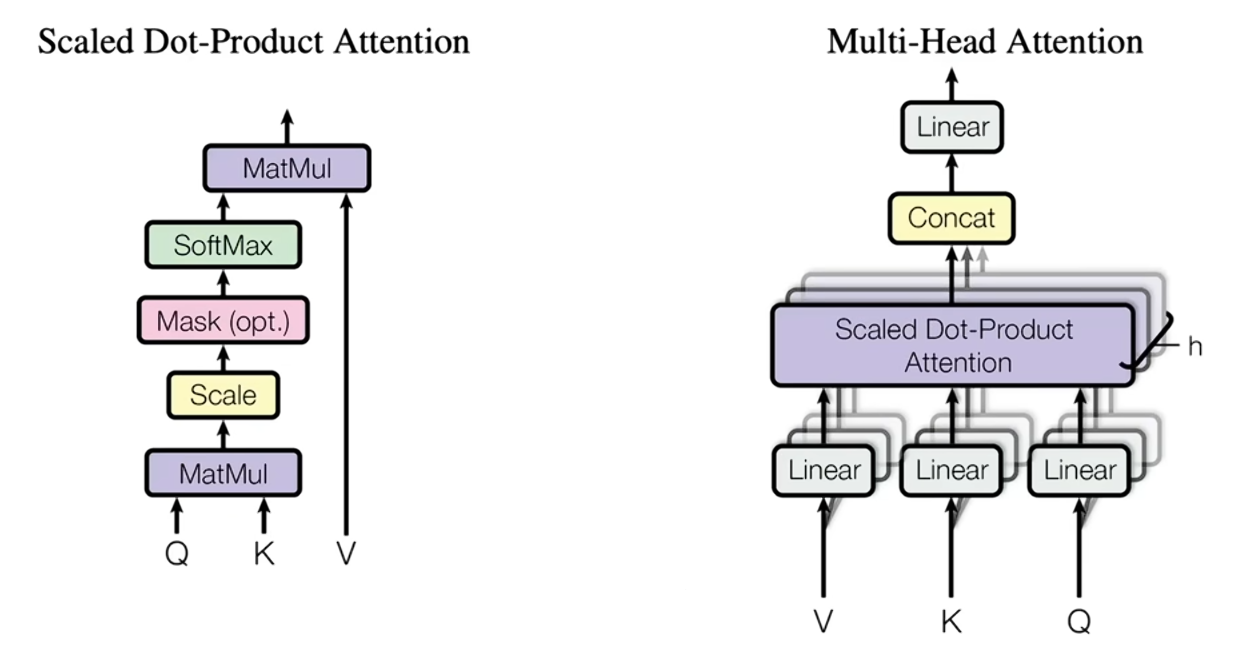

下面我们继续在v2.py里引入使用它，这一次改动的内容如下：
1. 从单头自注意力升级为多头自注意力（Multi-Head Self-Attention）
- 原始：使用单个Head模块，仅在一个特征子空间中计算注意力权重并聚合信息，模型只能从单一角度理解词元间的关系。

- 改进后：新增MultiHeadAttention类，内部通过nn.ModuleList并行管理多个独立的Head实例（数量为num_heads=4）。每个头拥有自己独立的Q/K/V投影层，分别在不同的投影子空间中计算注意力，从而能够捕捉多种不同类型的上下文依赖模式（例如：一个头关注邻近词、另一个头关注远距离语法结构等）。

2. 注意力输出的拼接与维度恢复
- 原始：单头输出形状为(B, T, head_size)，其中head_size = n_embd（即32），直接保持维度不变。

- 改进后：每个头的head_size缩小为n_embd // num_heads（即32/4=8），这样4个头各自输出(B, T, 8)，通过torch.cat(..., dim=-1)在最后一维拼接，重新得到(B, T, 32)。这种维度分割与拼接的设计使得总参数量与单头（head_size=32）时基本相当，但获得了多子空间的表达能力。

3. 模型容量的提升而不增加嵌入维度
- 原始：注意力模块参数量约为 3 * (n_embd * head_size)（Q/K/V三个线性层）。

- 改进后：多头情况下，总参数量为 num_heads * 3 * (n_embd * (n_embd // num_heads)) = 3 * n_embd * n_embd，与单头head_size=n_embd时相同，但拆分为多个独立的小头，在参数量不变的前提下，增强了模型的表示能力和鲁棒性。

4. 为后续堆叠更复杂的Transformer块做准备
- 原始：模型直接嵌入 → 单头注意力 → 输出，结构相对简单。

- 改进后：多头注意力是Transformer架构的标配组件。本次改动使模型结构更接近经典的Transformer编码器层（通常还会包含前馈网络和残差连接），为下一步添加多层堆叠、前馈网络、层归一化等模块铺平了道路。

下面对照原论文里的神经网络结构，阶段性总结一下我们目前的成果

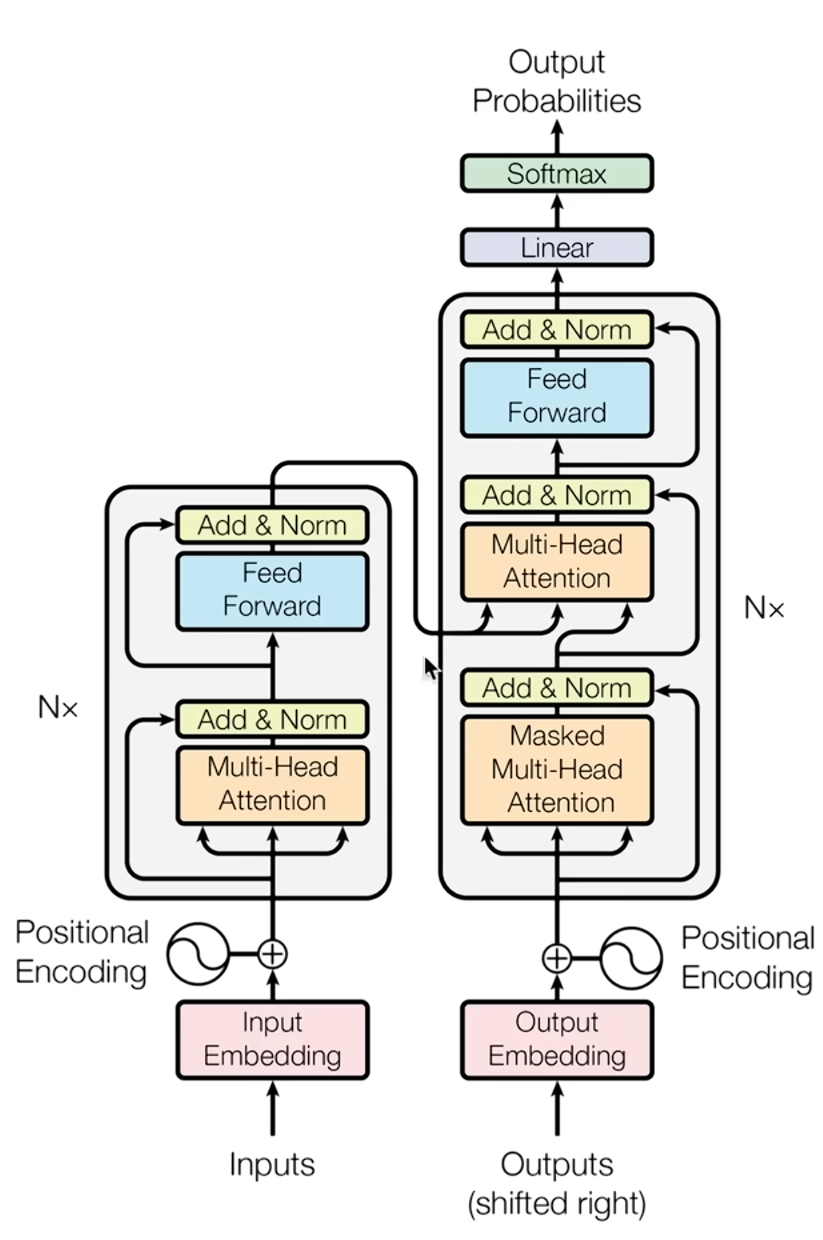

目前我们已经实现了的部分是一个多头self-attention，另一个多头cross-attention我们暂时还没有做，然后对照论文，原论文中每个 Transformer 层还包含一个前馈网络（Feed‑Forward Network, FFN），即一个简单的多层感知机（MLP）。其作用在于：经过自注意力层完成 token 间的“信息交流”后，FFN 对每个位置的表示进行独立的非线性变换，为模型提供额外的学习容量。这种设计相当于给予 token 在“交流”之后一个“思考”和“消化”的过程，而不是直接将注意力输出映射为最终的 logits，从而显著提升了模型的表示能力和泛化性能。

下面我们继续改进v2.py，引入FFN，具体改动如下：
1. 新增前馈网络模块（FeedForward）
- 原始：在多头自注意力之后，直接通过 lm_head 线性层输出 logits，没有额外的非线性变换层。

- 改进后：定义了一个独立的 FeedForward 类，内部包含一个简单的 线性层（Linear） 后接 ReLU 激活函数。该模块对每个位置的表示独立地进行非线性映射，增强了模型的表达能力。

2. 插入前馈网络到主模型的数据流中
- 原始：前向传播路径为：嵌入 → 多头自注意力 → 线性输出（lm_head）。

- 改进后：路径变为：嵌入 → 多头自注意力 → 前馈网络 → 线性输出（lm_head）。即在注意力机制完成 token 间的信息聚合后，增加了一个 逐位置的非线性变换层，让每个位置的表示经过“思考”后再映射到 logits。

实际上，人们会把刚才的那些部分打包成一个个BLock块，这些Block块包含刚才提到的多头注意力、FNN等模块，这样再构造神经网络时，就可以之间用封装好的Block块来写，我们为v2.py继续引入Block，改动如下：

1. 新增 Block 模块封装注意力与前馈
- 原始：在 BigramLanguageModel 中直接顺序调用 MultiHeadAttention 和 FeedForward，二者处于平级关系。

- 改进后：定义 Block 类，将 多头自注意力（MultiHeadAttention） 和 前馈网络（FeedForward） 组合成一个独立模块。这体现了 Transformer 中“通信（注意力）→ 计算（前馈）”的标准层结构，为重复堆叠提供了整洁的封装。

2. 堆叠多个 Transformer Block 增加模型深度
- 原始：仅包含单层注意力+前馈。

- 改进后：在 BigramLanguageModel 中使用 nn.Sequential 连续放置 3 个 Block（每个使用 n_head=4）。这使模型从“浅层单层”升级为“深层多层”，能够逐层抽象和提取更高阶的上下文特征，显著提升表示能力。

3. 引入 nn.Sequential 简化前向流程
- 原始：前向传播中显式调用 sa_head 和 ffwd。

- 改进后：通过 self.blocks 统一管理所有层，只需调用一次 x = self.blocks(x) 即可顺序执行多个 Block，代码更简洁、扩展性更强（后续增减层数只需调整列表长度）。

然而，若直接以现有神经网络架构进行训练，效果往往不尽如人意。原因在于，我们已迈入深层神经网络的训练范畴，而深层网络在优化过程中会面临诸多挑战（如梯度消失、梯度爆炸等）。幸运的是，原始论文中已提供了相应的解决方案。具体而言，有两种方法可确保深层神经网络在训练过程中保持可优化性：

第一种方法是跳跃连接（Skip Connection），即大名鼎鼎的残差连接（Residual Connection）。该方法源自2015年何凯明等人发表的著名论文《Deep Residual Learning for Image Recognition》。其核心思想是：在前向传播过程中，除了让数据依次流过各层之外，同时额外保留一条跳跃连接（skip connection），将前面层的特征直接传递到后续层，从而有效缓解梯度消失问题，使得极深网络也能稳定训练。

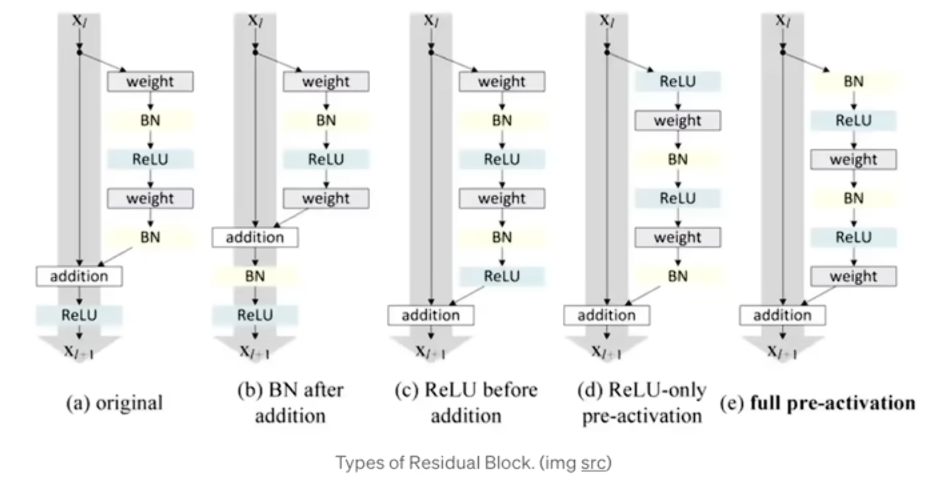



从实现层面看，残差连接的操作可以这样理解：设有一条贯穿整个网络的主路径（residual pathway），数据沿此路径自上而下流动。在每一层，我们可以从主路径上“分叉”出一路数据，送入该层的变换函数（如自注意力或前馈网络）进行计算，然后通过逐元素加法将计算结果加回到主路径上。因此，整个前向传播过程本质上就是：从输入到输出，一步一加，层层累加。

这一设计能够有效训练深层网络，其数学直觉来自于我们在第一课 Micrograd 中已经接触过的反向传播性质：加法节点的梯度分配是等价的——它会将上游传来的梯度副本分别传递给每一个输入分支。这意味着残差主路始终能获得完整的梯度信号，不会因为网络的加深而衰减；同时各个子层也能独立地获得与其输出等量的梯度，从而保证了参数更新的有效性。

下面我们就在v2.py中继续改进，做的改动如下：
1. 在多头注意力后添加输出投影层（proj）
- 原始：MultiHeadAttention 仅将多个头的输出拼接，直接返回形状 (B, T, num_heads * head_size)，即 (B, T, n_embd)。

- 改进后：新增一个线性层 self.proj = nn.Linear(num_heads * head_size, n_embd)，对拼接结果进行线性变换与维度保持。这相当于对多头聚合后的信息再做一次整合，有助于提升特征的表示质量。

2. 将前馈网络从单层扩展为标准的两层 MLP（扩展-收缩）
- 原始：FeedForward 仅包含一个线性层（n_embd → n_embd）和 ReLU。

- 改进后：采用 Transformer 论文中的经典设计：
    - 线性层（n_embd → 4 * n_embd） → ReLU → 线性层（4 * n_embd → n_embd）。
    - 中间隐藏层维度扩增 4 倍，大幅增加了模型的非线性能力和表示容量，同时最终投影回原始维度保持接口一致。

3. 在 Block 中引入残差连接（Residual Connection）
- 原始：Block 顺序执行 sa 和 ffwd，无跳跃连接，输入信息直接流过各层。

- 改进后：每个子模块（注意力和前馈）的输出均与输入相加：x = x + self.sa(x) 和 x = x + self.ffwd(x)。这确保了梯度能够更顺畅地反向传播，允许训练更深的网络，也保留了一部分原始输入信息，缓解退化问题。

经过上述改进（引入残差连接），训练后val loss下降至约 2.08。观察生成结果，尽管输出文本仍略显杂乱，但已经能够辨别出一些近似英文的结构，这表明我们的改动确实产生了积极效果。不过，我们也注意到train loss已低于val loss，这表明模型可能存在过拟合（overfitting）的迹象。

讲完残差连接，接下来我们介绍第二种方法——层归一化（Layer Normalization）。

实际上，Layer Norm 与 批归一化（Batch Normalization） 在思路上高度相似。回顾我们第4课（Makemore Part 3），当时重点讲解了 Batch Normalization。BN 的核心思想是：在批次维度（batch dimension） 上，对每一个独立的神经元进行归一化，使其输出分布近似为单位高斯分布（即均值为0、方差为1），从而加速训练并稳定收敛。

下面我们就来进行 Layer Norm

In [ ]:
class LayerNorm1d:

    def __init__(self, dim, eps=1e-5):
        self.eps = eps
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

    def __call__(self, x):
        # calculate the forward pass
        xmean=x.mean(1, keepdim=True)   
        xvar=x.var(1, keepdim=True)     # 这里把dim从0换成1，就实现了对每个样本的特征维度做归一化，而不是对整个batch的特征维度做归一化，从BN到LN的转变

        xhat=(x-xmean)/torch.sqrt(xvar+self.eps)    
        self.out = self.gamma * xhat + self.beta
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

对比BN代码，其实LN的代码非常简单，我们只是把BN代码里的对每一列处理换成了对每一行处理，同时去掉了那些无用的buffer缓冲什么的

这里karpathy又额外提了一点，他说之前讲过，transformer架构自从提出之后到现在(这里指的是他录视频的时候)5年以来，基本没有什么大改动，但是这里的Add&Norm部分，实则相较于原始论文，是做了一些变动的。原始论文里可以看到Add&Norm层是在transformer层之后应用的，但是目前比较常见的作法是把它放在transformer层之前，这被称之为(pre norm formulation)，这也是我们将对v2.py代码进行改动地方，具体的变动如下：

1. 在每个 Block 内部添加层归一化（LayerNorm）
- 原始：Block 中仅有自注意力和前馈网络，无归一化层。

- 改进后：为每个子模块（注意力和前馈）分别添加了 nn.LayerNorm(n_embd)，并将归一化置于子模块之前（即 Pre‑LN 结构）：
    - x = x + self.sa(self.ln1(x)) 和 x = x + self.ffwd(self.ln2(x))。
    - 这种设计能有效缓解深层网络中的梯度消失/爆炸问题，提升训练稳定性，且已被多数现代 Transformer 实现（如 GPT）采用。

2. 在模型输出前添加最终层归一化
- 原始：嵌入经过多个 Block 后直接送入 lm_head。

- 改进后：在 self.blocks 序列的末尾添加了一个额外的 nn.LayerNorm(n_embd)，对堆叠 Block 的输出进行最终归一化，再送入线性分类层。这进一步稳定了最后的特征分布，有助于提升预测性能。

下面我们的神经网络几乎也就完成了，我们接下来就会开展一些scale来测试我们的神经网络，再次之前，我们还是对v2.py进行了一些改动，来使得它方便我们的测试，具体改动如下：

1. 大幅提升模型容量（超参数升级）
- 原始：block_size=8, n_embd=32, n_head=4（隐式），n_layer=3（固定）。
- 改进后：
    - block_size 增至 256（上下文窗口扩大 32 倍）；
    - n_embd 增至 384（嵌入维度扩大 12 倍）；
    - 新增 n_head=6 和 n_layer=6，显式控制头数和层数；
    - batch_size 增至 64，学习率调整为 3e-4（适配更大模型）。

2. 引入 Dropout 正则化防止过拟合
- 原始：所有层均无 dropout。
- 改进后：
    - 在 Head 中定义 self.dropout（虽未在 forward 中使用，但预留接口）；
    - 在 MultiHeadAttention 的投影层后添加 self.dropout（同样未调用）；
    - 在 FeedForward 的最终投影层后添加 nn.Dropout(dropout)，对前馈输出进行随机丢弃。

3. 动态构建多层堆叠，提升扩展性
- 原始：使用 nn.Sequential 手动列出 3 个 Block。
- 改进后：采用列表推导式 [Block(...) for _ in range(n_layer)] 配合 * 解包，使得层数由超参数 n_layer 统一控制，便于后续调整模型深度。


这里再稍微介绍一下dropout。dropout来自于2014年的论文《Dropout: A Simple Way to Prevent Neural Networks form Overfitting》。它的具体做法就是在每次正向反向传播的过程中，随机丢弃掉几个神经元，train without them。由于每次丢弃掉的神经元都是不一样的，它最后造成的结果就是训练处某种一些子神经网络的集合。然后在测试时，所有的神经元又都被使用，这些sub神经网络就会融合成一个更好的神经网络，从而输出更好的结果

不过可惜的是，这个神经网络的参数量实在是太大了，我用4060笔记本试试了，跑300步就花了我5min，这里就不在本地跑了。karpathy用他的A100跑了15min，最后train loss 1.0763，val loss 1.4873，输出的结果已经很可观了

目前，我们已基本复现了论文中的字符级Transformer神经网络，但在架构上与原文存在显著差异。具体而言，我们实现的是一个仅解码器（decoder-only）的Transformer模型，其中并未包含编码器模块，也未引入交叉注意力（cross-attention）层。每个基础块仅由自注意力（self-attention）和前馈网络（feed-forward）构成。

之所以采用这种简化设计，是因为我们的任务目标仅为无条件文本生成——模型仅依赖于给定数据集进行自回归式生成，而不需要依赖任何外部条件输入。这一点在实现上体现为自注意力层中使用的下三角掩码矩阵（lower-triangular mask）：该掩码确保了每个token只能关注其之前的token，从而赋予模型自回归性质，这正是解码器（decoder）的核心特征。若移除该掩码，则模型将变为编码器（encoder），允许所有token之间相互“看见”，实现双向交流。

相比之下，原论文采用完整的编码器-解码器（encoder-decoder）架构，这是因为其面向的是机器翻译任务，生成过程天然依赖于条件信息。例如，编码器接收一段法文，并对其做完整、双向的理解（无掩码），然后将编码后的表征作为外部信息传递给解码器。此时，解码器的查询（queries）仍来自自身输入，但键（keys）和值（values）则来自编码器的输出，通过交叉注意力机制实现“条件生成”。这样一来，解码器的输出不仅受已生成上文的影响，还受到完整法文语义的约束，从而保证翻译的准确性。

简而言之，我们的decoder-only模型是原论文解码器部分的独立子集，适用于无条件的自回归生成；而原文的全套架构则面向有条件的序列转换任务，二者的差异源于任务本质的不同。这一认识为后续可能的扩展（如引入条件控制）奠定了清晰的基础。

下面，karpathy又继续介绍了如果我们想训练ChatGPT，我们该如何操作。他把训练的过程分为两部分，第一阶段是pre-training stage，第二阶段是fine-tuning stage。

在第一阶段 pre-training stage 里，我们用一大堆互联网的数据集来训练，得到一个 decoder-only transformer，这个transformer也只能够去babble text。可以说这个阶段和我们这节课干的事情非常类似，只不过是在更大更多的规模上——OpenAI不用character level，它们用subword，它们的vocabulary大概有50000多，它们的模型参数规模也更大。查阅GPT3的论文，可以看到GPT3有175B的参数，96层，12288的embd，96个head，128的head_size，batchsize达到了3.2M，在300B的token上训练。

在完成这一阶段后，我们得到的本质上就是给document completer，它也只能babbles，只不过给出的是互联网数据。它能做到的也就是完成句子(complete sequence)。所以在第二阶段的 fine-tuning stage 里，我们做的就是让它能够变成一个assistant。这一阶段也大体上分为三个步骤。
- step 1: 收集演示数据并训练有监督策略(collect demonstration data and train a supervised policy)
    - 这一步简单说就是收集大量的Q&A风格的数据集去fine-tuning，让模型知道输入一个问题后要给出答案这样的对话格式
- step 2: 收集对比数据并训练奖励模型(collect comparsion data and train a reward model)
    - 这一步就是让模型回答问题，然后让不同人去打分，用这个结果数据训练一个奖励模型
- step 3: 使用PPO强化学习算法针对奖励模型优化策略(Optimize a policy against the reward model using the PPO reinforcement learning algorithm)
    - 这一步让模型自己大量生成句子，给这些生成的句子打分，然后根据分数反馈，反向调整模型参数，以期生成更高分的句子

ok，现在最后我们总结一下这节课的内容。我们根据祖师爷级论文《Attention Is All You Need》训练了一个decoder-only transformer，这基本上就是一个GPT。我们在Tiny Shakespeare数据集上训练，并且得到不错的结果